In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from importlib import reload
import matplotlib.pyplot as plt
import seaborn as sns
import data_processing
import random
import tensorflow as tf
import os
import shap

c:\Users\juble\miniconda3\envs\tf_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
tf.compat.v1.disable_v2_behavior()

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
import gc
gc.collect()

0

In [3]:
h2o_data = xr.open_dataset('ACEFTS_L2_v5p2_H2O.nc')
h2o_flags = xr.open_dataset('ACEFTS_L2_v5p2_flags_H2O.nc')

In [4]:
h2o_data = h2o_data.set_index(index=['orbit', 'sunset_sunrise'])
h2o_flags = h2o_flags.set_index(index=['orbit', 'sunset_sunrise'])

In [5]:
reload(data_processing)
import data_processing
from data_processing import preprocess_profile_data as ppd

In [5]:
date_indices = np.arange(len(h2o_data['year'].values))

In [11]:
features, labels, feature_date_indices = ppd('H2O', 
                                             h2o_data, 
                                             h2o_flags, 
                                             date_indices, 
                                             n_surrounding = 4, 
                                             n_altitudes = len(h2o_data['altitude'].values),
                                             filter_indices = True
                                             )

VMR for date index 256 is empty after screening
VMR for date index 1753 is empty after screening
VMR for date index 2319 is empty after screening
VMR for date index 2506 is empty after screening
VMR for date index 4293 is empty after screening
VMR for date index 4316 is empty after screening
VMR for date index 4591 is empty after screening
VMR for date index 4683 is empty after screening
VMR for date index 4695 is empty after screening
VMR for date index 4773 is empty after screening
VMR for date index 5448 is empty after screening
VMR for date index 5617 is empty after screening
VMR for date index 5743 is empty after screening
VMR for date index 6082 is empty after screening
VMR for date index 6844 is empty after screening
VMR for date index 7916 is empty after screening
VMR for date index 7917 is empty after screening
VMR for date index 7977 is empty after screening
VMR for date index 7989 is empty after screening
VMR for date index 8142 is empty after screening
VMR for date index 83

In [ ]:
# Save features, labels and feature date indices as .npz file

# Specify the path to your USB drive
save_dir = "/Volumes/USB DRIVE/MPhys Project Data"
save_dir = "E:\MPhys Project Data"

# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Save all arrays in a single .npz file
np.savez_compressed(
    os.path.join(save_dir, "data_1.npz"),
    features=features,
    labels=labels,
    feature_date_indices=feature_date_indices
)

In [6]:
# Load the .npz file
#save_dir = "/Volumes/USB DRIVE/MPhys Project Data"
save_dir = "E:\MPhys Project Data"
data = np.load(os.path.join(save_dir, "data.npz"))
features = data["features"]
labels = data["labels"]
feature_date_indices = data["feature_date_indices"]

In [7]:
features = features.astype('float32')
labels = labels.astype('int32')
feature_date_indices = feature_date_indices.astype('int32')

In [407]:
n_profiles = features.shape[1]
n_altitudes = 150
n_features = features.shape[3] - 1

In [9]:
features.shape

(125194, 5, 150, 11)

In [19]:
features_reduced = np.delete(features, 1, axis=-1)
n_features = features_reduced.shape[3] - 1

In [13]:
features_reduced.shape

(125194, 5, 150, 10)

In [13]:
labels.shape
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))

{0: 124340, 1: 854}


In [9]:
from keras import layers, models
from tensorflow.keras.layers import Layer
from keras.optimizers import Adam
from keras.regularizers import l2
import tensorflow.keras.backend as K


In [402]:


def binary_accuracy(y_true, y_pred):
    """
    Custom accuracy metric for binary classification with a threshold.
    """
    y_pred_discrete = tf.cast(y_pred > 0.5, tf.float32)
    return tf.keras.metrics.binary_accuracy(y_true, y_pred_discrete)

def class0_accuracy(y_true, y_pred):
    """
    Computes accuracy for class 0 (i.e. for samples where y_true == 0).
    """
    y_pred_discrete = tf.cast(y_pred > 0.5, tf.float32)
    # Create a mask for class 0 samples.
    mask = tf.cast(tf.equal(y_true, 0.), tf.float32)
    correct = tf.cast(tf.equal(y_pred_discrete, y_true), tf.float32)
    # Sum correct predictions only for class 0 and normalize by the count.
    return tf.reduce_sum(correct * mask) / (tf.reduce_sum(mask) + 1e-7)

def class1_accuracy(y_true, y_pred):
    """
    Computes accuracy for class 1 (i.e. for samples where y_true == 1).
    """
    y_pred_discrete = tf.cast(y_pred > 0.5, tf.float32)
    mask = tf.cast(tf.equal(y_true, 1.), tf.float32)
    correct = tf.cast(tf.equal(y_pred_discrete, y_true), tf.float32)
    return tf.reduce_sum(correct * mask) / (tf.reduce_sum(mask) + 1e-7)

def recall_1(y_true, y_pred):
    """
    Computes recall for class 1 with a threshold of 0.5.
    Recall for class 1 = TP / (TP + FN)
    where:
      - TP: # of samples where y_true=1 AND y_pred=1
      - FN: # of samples where y_true=1 AND y_pred=0
    """
    # Convert predicted probabilities to discrete 0/1
    y_pred_discrete = tf.cast(y_pred > 0.5, tf.float32)
    
    # True Positives for class 1
    tp = tf.reduce_sum(tf.cast(
        tf.logical_and(
            tf.equal(y_true, 1.0),
            tf.equal(y_pred_discrete, 1.0)
        ), 
        tf.float32
    ))
    
    # False Negatives for class 1
    fn = tf.reduce_sum(tf.cast(
        tf.logical_and(
            tf.equal(y_true, 1.0),
            tf.equal(y_pred_discrete, 0.0)
        ), 
        tf.float32
    ))
    
    return tp / (tp + fn + 1e-7)

def recall_0(y_true, y_pred):
    """
    Computes recall for class 0 with a threshold of 0.5.
    Recall for class 0 = TP / (TP + FN)
    where:
      - TP: # of samples where y_true=0 AND y_pred=0
      - FN: # of samples where y_true=0 AND y_pred=1
    """
    y_pred_discrete = tf.cast(y_pred > 0.5, tf.float32)
    
    # True Positives for class 0
    tp = tf.reduce_sum(tf.cast(
        tf.logical_and(
            tf.equal(y_true, 0.0),
            tf.equal(y_pred_discrete, 0.0)
        ), 
        tf.float32
    ))
    
    # False Negatives for class 0
    fn = tf.reduce_sum(tf.cast(
        tf.logical_and(
            tf.equal(y_true, 0.0),
            tf.equal(y_pred_discrete, 1.0)
        ), 
        tf.float32
    ))
    
    return tp / (tp + fn + 1e-7)


class ContextualAttention(Layer):
    def __init__(self):
        super(ContextualAttention, self).__init__()

    def call(self, query, key, value, indicator):
        """
        Contextual attention mechanism.

        Parameters:
        - query, key, value: Outputs from the LSTM or similar layers.
        - indicator: Binary indicator for the current profile (shape: [batch_size, n_profiles]).
        
        Returns:
        - attention_output: Weighted sum of value vectors.
        - attention_weights: Attention scores for all profiles.
        """
        # Compute raw attention scores (dot product between query and key)
        scores = tf.matmul(query, key, transpose_b=True)  # [batch_size, n_profiles, n_profiles]

        # Scale scores to avoid large values
        scores = scores / tf.sqrt(tf.cast(tf.shape(key)[-1], tf.float32))

        # Add bias for the current profile
        current_profile_bias = tf.expand_dims(indicator, axis=1)  # [batch_size, 1, n_profiles]
        scores += current_profile_bias * 3  # Encourage attention on the current profile

        # Normalize scores using softmax
        attention_weights = tf.nn.softmax(scores, axis=-1)  # [batch_size, n_profiles, n_profiles]

        # Compute weighted sum of value
        attention_output = tf.matmul(attention_weights, value)  # [batch_size, n_profiles, value_dim]

        return attention_output, attention_weights
    
def compute_saliency_with_contextual_attention(model, X, indicators):
    """
    Compute saliency with the contextual attention model.
    """
    X_tensor = tf.convert_to_tensor(X)
    indicators_tensor = tf.convert_to_tensor(indicators)

    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        predictions = model([X_tensor, indicators_tensor])
    gradients = tape.gradient(predictions, X_tensor)
    return np.abs(gradients.numpy())


def focal_loss(gamma=1, alpha=0.75):
    """
    Focal Loss for binary classification.
    gamma: focusing parameter (float)
    alpha: weight for class 1 (float between 0 and 1)
    """
      # Convert python floats to tf.float32 for safety
    alpha_t = tf.constant(alpha, dtype=tf.float32)
    gamma_t = tf.constant(gamma, dtype=tf.float32)

    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)

        # Clip predictions to avoid numerical issues
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        # Focal Loss
        # FL = - alpha * y_true * (1 - y_pred)^gamma * log(y_pred)
        #      - (1 - alpha) * (1 - y_true) * (y_pred^gamma) * log(1 - y_pred)

        pt1 = alpha_t * y_true * tf.pow((1 - y_pred), gamma_t) * tf.math.log(y_pred)
        pt2 = (1 - alpha_t) * (1 - y_true) * tf.pow(y_pred, gamma_t) * tf.math.log(1 - y_pred)

        return -tf.reduce_mean(pt1 + pt2)
    return focal_loss_fixed

def focal_loss_with_logits(gamma=2.0, alpha=0.75):
    """
    Focal Loss for binary classification working on logits.
    gamma: focusing parameter.
    alpha: balancing factor for the positive class.
    """
    def loss_fn(y_true, logits):
        # Ensure y_true is float32
        y_true = tf.cast(y_true, tf.float32)
        # Compute standard sigmoid cross-entropy (logits version)
        ce = tf.nn.sigmoid_cross_entropy_with_logits(labels=y_true, logits=logits)
        # Convert logits to probabilities for the modulating factor
        pred_prob = tf.nn.sigmoid(logits)
        # p_t: probability of the correct class for each sample
        p_t = y_true * pred_prob + (1 - y_true) * (1 - pred_prob)
        # Modulating factor: (1 - p_t)^gamma
        modulating_factor = tf.pow(1 - p_t, gamma)
        # Alpha factor: weights for each class
        alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
        # Focal Loss
        loss = alpha_factor * modulating_factor * ce
        return tf.reduce_mean(loss)
    return loss_fn

In [403]:
def build_contextual_cnn_lstm_model(n_profiles, n_altitudes, n_features):
    inputs = tf.keras.Input(shape=(n_profiles, n_altitudes, n_features), name = 'Features')
    indicators = tf.keras.Input(shape=(n_profiles,), name = 'Attention_Indicators')  # Input for indicator feature

    # Extract just the altitude-dependent features (VMR, altitude)
    altitude_dependent_features = inputs[:, :, :, :2]  # Assuming first 2 features are VMR & altitude

    # Extract the time & latitude features separately
    time_latitude_features = inputs[:, :, 0, 2:]  # Assuming time & latitude are the last features


    # Time-distributed CNN layers
    cnn = layers.TimeDistributed(
        models.Sequential([
            layers.Conv1D(filters=64, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-3)),
            layers.MaxPooling1D(pool_size=2),
            #layers.Dropout(0.3),
            layers.Conv1D(filters=128, kernel_size=5, activation='relu', kernel_regularizer=l2(1e-3)),
            layers.MaxPooling1D(pool_size=2),
            #layers.Dropout(0.3),
            layers.Conv1D(filters=256, kernel_size=7, activation='relu', kernel_regularizer=l2(1e-3)),
            layers.MaxPooling1D(pool_size=2),
            #layers.Dropout(0.3),
            layers.Flatten()
        
        ]),
        name = 'Time_Distributed_CNN'
    )(altitude_dependent_features)


    # Merge CNN output with time & latitude features
    merged_features = layers.Concatenate(axis=-1)([cnn, time_latitude_features])  # Shape: (None, 5, CNN_output_size + 8)

    # LSTM layer
    lstm = layers.LSTM(128, return_sequences=True, kernel_regularizer=l2(1e-3), recurrent_regularizer=l2(1e-4), name = 'LSTM')(merged_features)

    # Contextual Attention layer
    attention_layer = ContextualAttention()
    attention_output, attention_weights = attention_layer(lstm, lstm, lstm, indicators)

    # Aggregate attention output along profiles
    aggregated_attention = layers.GlobalAveragePooling1D(name = 'Aggregated_Attention')(attention_output)

    # Fully connected layers
    dense = layers.Dense(64, activation='relu', kernel_regularizer=l2(1e-4), name = 'Aggregated_Features')(aggregated_attention)
    outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=l2(1e-3), name = 'Output')(dense)

    # Build the model
    model = tf.keras.Model(inputs=[inputs, indicators], outputs=outputs)

    # Compile the model
    optimizer = Adam(learning_rate=1e-4)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', 
                  metrics=[binary_accuracy,
                           recall_0,
                           recall_1])
    return model

In [ ]:
# Define the CNN-LSTM model
def build_cnn_lstm_model(n_profiles, n_altitudes, n_features):
    """
    Builds a CNN-LSTM model for profile classification.

    Parameters:
    - n_profiles: Number of profiles per sample.
    - n_altitudes: Number of altitude levels per profile.
    - n_features: Number of features per altitude.

    Returns:
    - model: Compiled CNN-LSTM model.
    """
    input_shape = (n_profiles, n_altitudes, n_features)

    # Input layer
    inputs = tf.keras.Input(shape=input_shape, name = 'Feature_Input')

    # Time-distributed CNN layers
    cnn = layers.TimeDistributed(
        models.Sequential([
            layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_altitudes, n_features), kernel_regularizer=l2(1e-3)),
            layers.MaxPooling1D(pool_size=2),
            layers.Conv1D(filters=128, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-3)),
            layers.MaxPooling1D(pool_size=2),
            layers.Flatten()
        ]),
        name = 'TimeDistributed_CNN'
    )(inputs)

    # LSTM layers
    lstm = layers.LSTM(128, return_sequences=True, kernel_regularizer=l2(1e-3), recurrent_regularizer=l2(1e-3), name = 'LSTM')(cnn)

    # Attention Layer
    attention_layer = layers.Attention()
    attention_scores = attention_layer([lstm, lstm], name = 'Contextual_Attention')  # Self-attention: query and key/value are the same
    attention_output = layers.GlobalAveragePooling1D()(attention_scores) # Aggregate the attention scores along profiles


    # Fully connected layers
    dense = layers.Dense(64, activation='relu', kernel_regularizer=l2(1e-4), name = 'Aggregated_Attention')(attention_output)
    outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=l2(1e-3), name = 'Output')(dense)  # Binary classification

    # Build the model
    model = models.Model(inputs=inputs, outputs=outputs)

    # Compile the model
    optimizer = Adam(learning_rate=1e-4)  # Lower the learning rate
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[binary_accuracy_with_threshold])

    return model


In [24]:
tf.debugging.set_log_device_placement(False)

In [408]:
model = build_contextual_cnn_lstm_model(n_profiles, n_altitudes, n_features)

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='cnn_lstm_model.png', show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [409]:
model.summary()

Model: "model_45"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Features (InputLayer)          [(None, 5, 150, 10)  0           []                               
                                ]                                                                 
                                                                                                  
 tf.__operators__.getitem_90 (S  (None, 5, 150, 2)   0           ['Features[0][0]']               
 licingOpLambda)                                                                                  
                                                                                                  
 Time_Distributed_CNN (TimeDist  (None, 5, 3584)     271168      ['tf.__operators__.getitem_90[0][
 ributed)                                                        0]']                      

In [18]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [13]:
# Split the data into training, validation, and test sets
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp, indices_train, indices_temp = train_test_split(features, labels, range(len(labels)), test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test, indices_val, indices_test = train_test_split(X_temp, y_temp, indices_temp, test_size=0.5, random_state=42)

In [14]:
X_train_indicators = X_train[..., -1]
X_train_indicators = X_train_indicators[:, :, 0]
X_train = X_train[..., :-1]

X_val_indicators = X_val[..., -1]
X_val_indicators = X_val_indicators[:, :, 0]
X_val = X_val[..., :-1]

X_test_indicators = X_test[..., -1]
X_test_indicators = X_test_indicators[:, :, 0]
X_test = X_test[..., :-1]



In [107]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

In [19]:
# Smoothed class weights

# Compute raw class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Apply logarithmic scaling
smoothed_weights = np.log1p(class_weights)

# Convert to dictionary for Keras
class_weights_dict = {i: smoothed_weights[i] for i in range(len(smoothed_weights))}

In [ ]:
# Intermediate Class weights

intermediate_weights = (class_weights + smoothed_weights)/2

class_weights_dict = {i: intermediate_weights[i] for i in range(len(intermediate_weights))}

In [417]:
gc.collect()

44208

Epoch 1/150
685/685 [==============================] - 11s 14ms/step - loss: 1.0261 - binary_accuracy: 0.6208 - recall_0: 0.6223 - recall_1: 0.2435 - val_loss: 0.7713 - val_binary_accuracy: 0.6499 - val_recall_0: 0.6509 - val_recall_1: 0.3152
Epoch 2/150
685/685 [==============================] - 8s 11ms/step - loss: 0.7368 - binary_accuracy: 0.6519 - recall_0: 0.6523 - recall_1: 0.3378 - val_loss: 0.7568 - val_binary_accuracy: 0.5539 - val_recall_0: 0.5525 - val_recall_1: 0.4598
Epoch 3/150
685/685 [==============================] - 8s 11ms/step - loss: 0.6680 - binary_accuracy: 0.6959 - recall_0: 0.6963 - recall_1: 0.3971 - val_loss: 0.7240 - val_binary_accuracy: 0.6081 - val_recall_0: 0.6071 - val_recall_1: 0.4632
Epoch 4/150
685/685 [==============================] - 8s 12ms/step - loss: 0.6481 - binary_accuracy: 0.7095 - recall_0: 0.7100 - recall_1: 0.3761 - val_loss: 0.5500 - val_binary_accuracy: 0.7892 - val_recall_0: 0.7905 - val_recall_1: 0.3736
Epoch 5/150
685/685 [==========

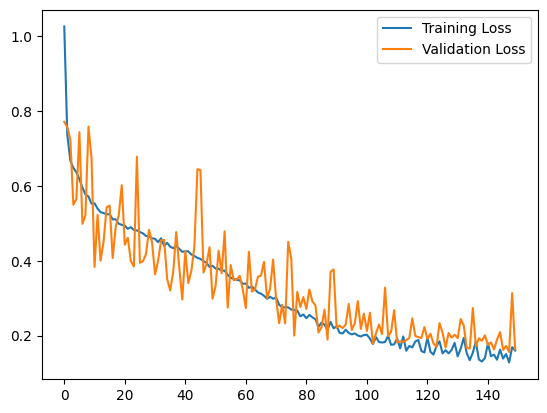

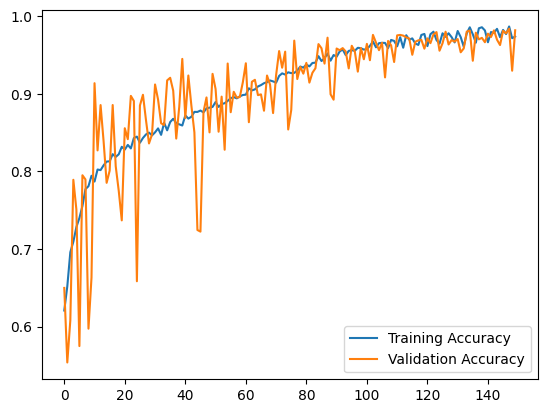

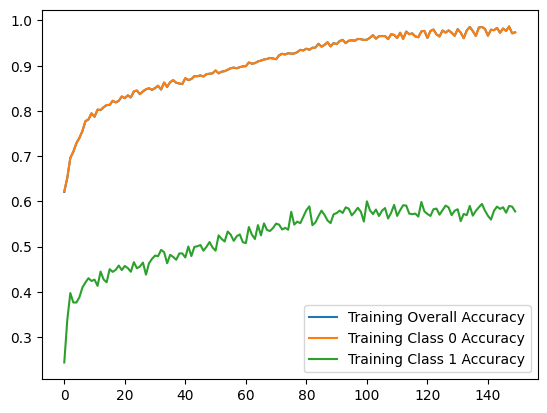

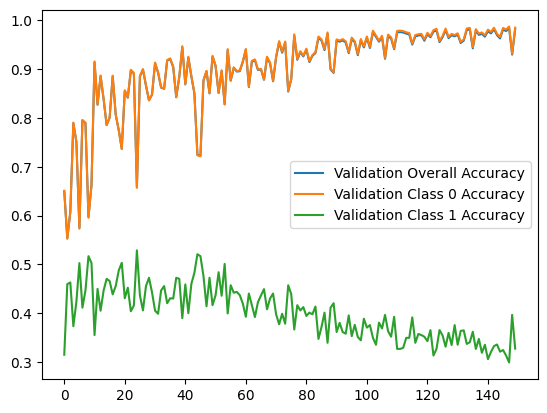

In [413]:
# Train the model
history = model.fit(
    [X_train, X_train_indicators], y_train,
    epochs=150,
    batch_size=128,
    validation_data=([X_val, X_val_indicators], y_val),
    #callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    class_weight=class_weight_dict
)

plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['binary_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_binary_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

# Plot accuracy metrics
plt.figure()
plt.plot(history.history['binary_accuracy'], label='Training Overall Accuracy')
plt.plot(history.history['recall_0'], label='Training Class 0 Accuracy')
plt.plot(history.history['recall_1'], label='Training Class 1 Accuracy')
plt.legend()
plt.show()

# Plot accuracy metrics
plt.figure()
plt.plot(history.history['val_binary_accuracy'], label='Validation Overall Accuracy')
plt.plot(history.history['val_recall_0'], label='Validation Class 0 Accuracy')
plt.plot(history.history['val_recall_1'], label='Validation Class 1 Accuracy')
plt.legend()
plt.show()

In [54]:
#model.save("/Volumes/USB DRIVE/MPhys Project Data/model.keras")
model.save("E:\MPhys Project Data\model_best_2.keras")

In [ ]:
model = tf.keras.models.load_model("/Volumes/USB DRIVE/MPhys Project Data/model.keras")

In [159]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate([X_test, X_test_indicators], y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

587/587 [==============================] - 2s 3ms/step - loss: 0.1477 - binary_accuracy_with_threshold: 0.9852
Test Loss: 0.14767925441265106, Test Accuracy: 0.9851970076560974


587/587 [==============================] - 2s 2ms/step
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     18647
           1       0.21      0.55      0.30       132

    accuracy                           0.98     18779
   macro avg       0.60      0.77      0.65     18779
weighted avg       0.99      0.98      0.99     18779



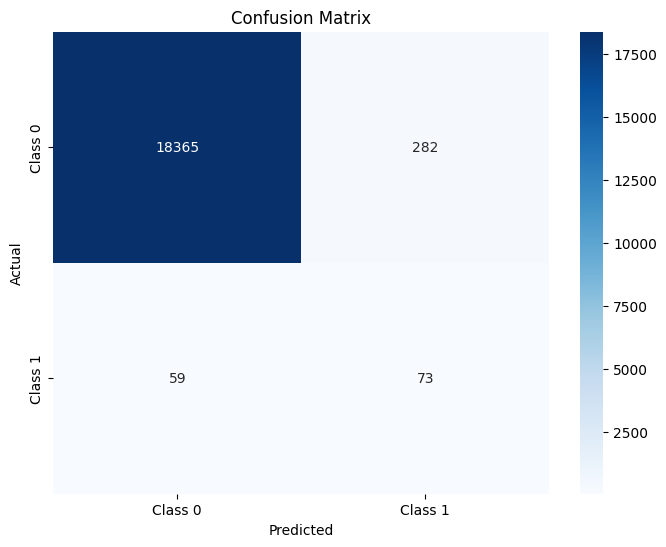

In [414]:
# Get predictions
predictions = model.predict([X_val, X_val_indicators])

# Convert probabilities to discrete labels
discrete_predictions = (predictions > 0.5).astype(int)

# Print classification report
print(classification_report(y_val, discrete_predictions))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_val, discrete_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

587/587 [==============================] - 2s 3ms/step
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     18655
           1       0.19      0.51      0.28       125

    accuracy                           0.98     18780
   macro avg       0.59      0.75      0.63     18780
weighted avg       0.99      0.98      0.99     18780



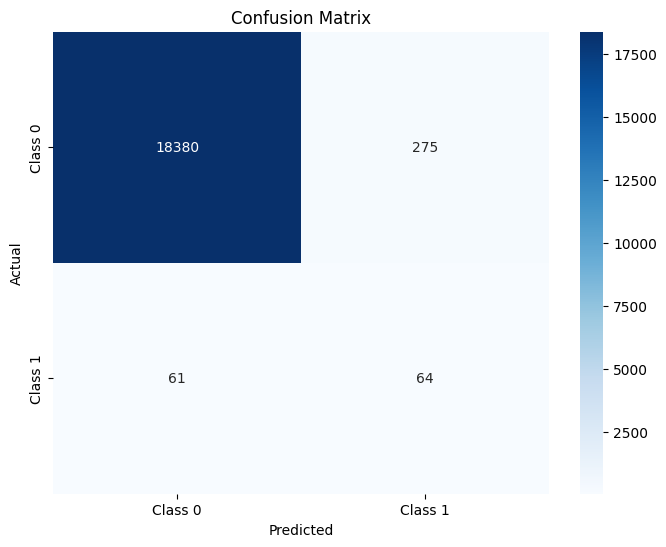

In [415]:
# Get predictions
predictions = model.predict([X_test, X_test_indicators])

# Convert probabilities to discrete labels
discrete_predictions = (predictions > 0.5).astype(int)

# Print classification report
print(classification_report(y_test, discrete_predictions))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, discrete_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

(2000, 5, 150, 10)


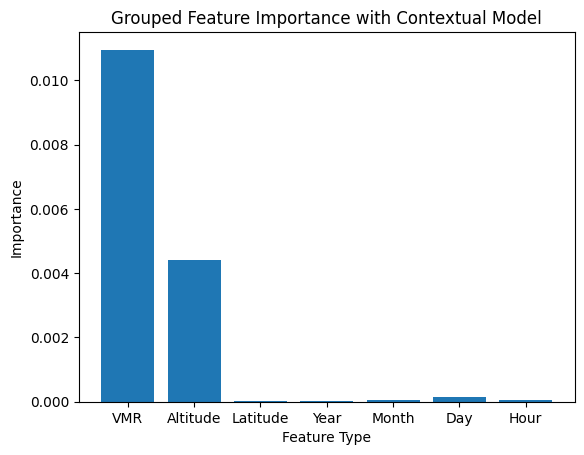

In [418]:
# Overall Feature importance for prediction

# Sample random indices for evaluation
random_indices = np.random.choice(X_test.shape[0], 2000, replace=False)
X_test_sample = X_test[random_indices]
X_test_sample_indicators = X_test_indicators[random_indices]
X_test_sample_indicators_perturbed = X_test_sample_indicators.copy()

# Compute saliency
saliency = compute_saliency_with_contextual_attention(model, X_test_sample, X_test_sample_indicators)
print(saliency.shape)

# Aggregate saliency over profiles and altitudes
feature_importance = np.mean(saliency, axis=(0, 1, 2))  # Aggregate across samples, profiles, and altitudes
n_altitudes = len(h2o_data['altitude'].values)
n_features = 10

# Define feature groups
feature_groups = {
    "VMR": feature_importance[0],
    "Altitude": feature_importance[1],
    "Latitude": feature_importance[2],
    "Year": feature_importance[3],
    "Month": np.sum(feature_importance[4:6]),
    "Day": np.sum(feature_importance[6:8]),
    "Hour": np.sum(feature_importance[8:10]),
}

# Visualize grouped feature importance
plt.bar(feature_groups.keys(), feature_groups.values())
plt.xlabel("Feature Type")
plt.ylabel("Importance")
plt.title("Grouped Feature Importance with Contextual Model")
plt.show()

In [23]:

random_indices = np.random.choice(X_test.shape[0], 2000, replace=False)
X_test_sample = X_test[random_indices]
X_test_sample_indicators = X_test_indicators[random_indices]

def compute_saliency(model, X):
    X_tensor = tf.convert_to_tensor(X)
    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        predictions = model(X_tensor)

    gradients = tape.gradient(predictions, X_tensor)
    return np.abs(gradients.numpy())

saliency = compute_saliency(model, X_test_sample)
print(saliency.shape)

# Aggregate over features
feature_importance = np.mean(saliency, axis=(0, 1, 2))  # Aggregate over profiles and altitudes
n_altitudes = 150
n_features = 11

feature_groups = {
    "VMR": feature_importance[0],
    "Altitude": feature_importance[1],
    "Latitude": feature_importance[2],
    "year": feature_importance[3],
    "month": np.sum(feature_importance[4:6]),
    "day": np.sum(feature_importance[6:8]),
    "hour": np.sum(feature_importance[8:10]),
    #"Time Features": np.sum(feature_importance[3:10]),  # Sum of 7 time features
    "Indicator": feature_importance[10],
}

# Visualize grouped feature importance
plt.bar(feature_groups.keys(), feature_groups.values())
plt.xlabel("Feature Type")
plt.ylabel("Importance")
plt.title("Grouped Feature Importance for Quality Prediction")
plt.show()

ValueError: Layer "model" expects 2 input(s), but it received 1 input tensors. Inputs received: [<tf.Tensor: shape=(2000, 5, 150, 10), dtype=float32, numpy=
array([[[[ 1.        ,  0.0367893 , -0.75266665, ...,  0.9189578 ,
          -0.7579811 ,  0.65227646],
         [ 0.83874464,  0.04347826, -0.75266665, ...,  0.9189578 ,
          -0.7579811 ,  0.65227646],
         [ 0.65584415,  0.05016723, -0.75266665, ...,  0.9189578 ,
          -0.7579811 ,  0.65227646],
         ...,
         [-0.1       , -0.1       , -0.75266665, ...,  0.9189578 ,
          -0.7579811 ,  0.65227646],
         [-0.1       , -0.1       , -0.75266665, ...,  0.9189578 ,
          -0.7579811 ,  0.65227646],
         [-0.1       , -0.1       , -0.75266665, ...,  0.9189578 ,
          -0.7579811 ,  0.65227646]],

        [[ 1.        ,  0.05685619, -0.75266665, ...,  0.9189578 ,
          -0.42103714,  0.9070434 ],
         [ 0.34864864,  0.06354515, -0.75266665, ...,  0.9189578 ,
          -0.42103714,  0.907043

In [254]:
predicted_bad_indices = np.where(discrete_predictions == 1)[0]
actual_bad_indices = np.where(y_test == 1)[0]
predicted_good_indices = np.where(discrete_predictions == 0)[0]

predicted_bad_indices_TP = np.intersect1d(predicted_bad_indices, actual_bad_indices)
predicted_good_indices_FP = np.intersect1d(predicted_good_indices, actual_bad_indices)

predicted_bad_indices_TP.shape
predicted_good_indices_FP.shape

(57,)

16106
[30463 30464 30465 30466 30467]


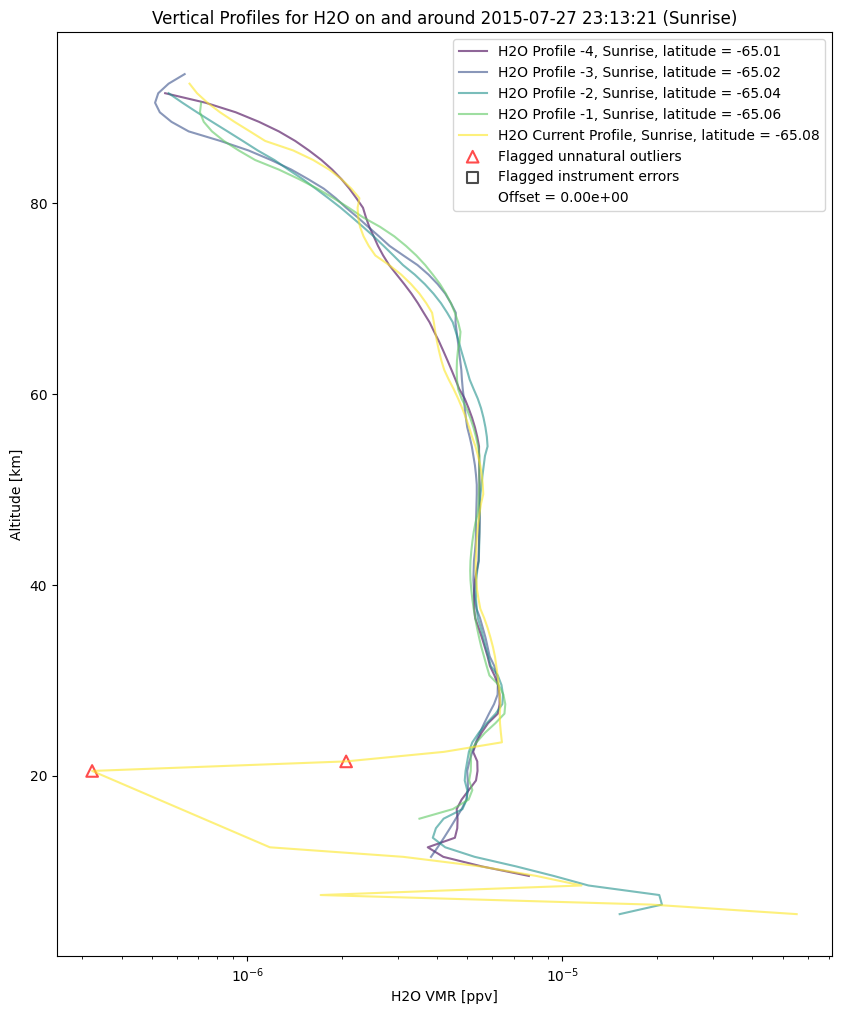

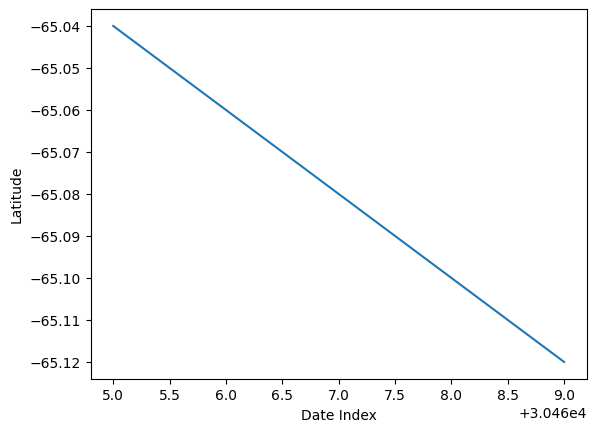

In [396]:
reload(data_processing)
from data_processing import vertical_profile_plot as vpp
#18612
idx = np.random.choice(predicted_good_indices_FP)
print(idx)

test_date_indices = feature_date_indices[indices_test]
date_indices_example = test_date_indices[idx]
print(date_indices_example)

date_indices_example_after = date_indices_example + 2

vpp('H2O', h2o_data, h2o_flags, date_indices_example)


latitudes = h2o_data['latitude'][date_indices_example_after].values
plt.figure()

plt.plot(date_indices_example_after, latitudes)
plt.xlabel('Date Index')
plt.ylabel('Latitude')
plt.show()


In [29]:


# Subset of the training data for background
background = [X_train[:500], X_train_indicators[:500]]

# Initialize SHAP Deep Explainer
explainer = shap.DeepExplainer(model, background)


c:\Users\juble\miniconda3\envs\tf_env\lib\site-packages\shap\explainers\_deep\deep_tf.py:99: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn("Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.")


In [30]:
X_test_sample = X_test[idx]
X_test_sample = X_test_sample[np.newaxis, ...]
X_test_sample_indicators = X_test_indicators[idx]
X_test_sample_indicators = X_test_sample_indicators[np.newaxis, ...]


# Single sample to explain
sample_to_explain = [X_test_sample, X_test_sample_indicators]

# Compute SHAP values
shap_values = explainer.shap_values(sample_to_explain, check_additivity=False)


In [31]:
# Extract SHAP values for the current profile (profile 4)
current_profile_shap = shap_values[0][:, 4, :]  # Assuming profile 4 corresponds to index 4
print(current_profile_shap.shape)
feature_names = ["VMR", "Altitude", "Latitude", "Year", "Month_Sin", "Month_Cos", "Day_Sin", "Day_Cos", "Hour_Sin", "Hour_Cos"] 


(1, 150, 10, 1)


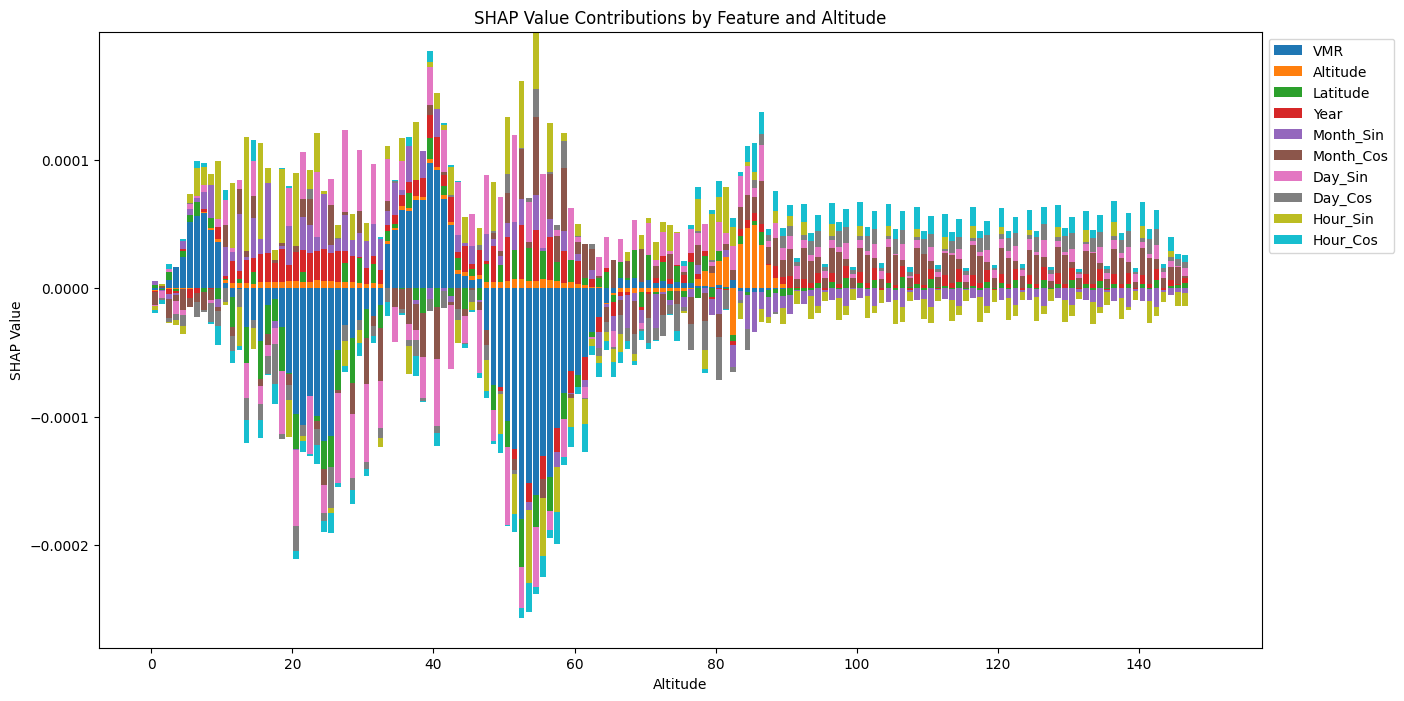

In [33]:
# Initialize cumulative sums for stacking
altitudes = h2o_data['altitude'].values
positive_cumulative = np.zeros_like(altitudes)
negative_cumulative = np.zeros_like(altitudes)

plt.figure(figsize=(15, 8))

for i, feature in enumerate(feature_names):
    # Extract SHAP values for the current feature
    feature_shap = current_profile_shap[0][:, i, 0]

    # Separate positive and negative contributions
    positive_contributions = np.maximum(0, feature_shap)
    negative_contributions = np.minimum(0, feature_shap)

    # Plot positive contributions
    plt.bar(
        altitudes,
        positive_contributions,
        bottom=positive_cumulative,
        label=feature,  # Label each feature only once
        color=f"C{i}"  # Unique color for each feature
    )
    positive_cumulative += positive_contributions  # Update positive stack

    # Plot negative contributions
    plt.bar(
        altitudes,
        negative_contributions,
        bottom=negative_cumulative,
        color=f"C{i}"  # Same color as the positive for this feature
    )
    negative_cumulative += negative_contributions  # Update negative stack

# Plot labels and legend
plt.xlabel("Altitude")
plt.ylabel("SHAP Value")
plt.title("SHAP Value Contributions by Feature and Altitude")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))  # Adjust legend position
plt.show()


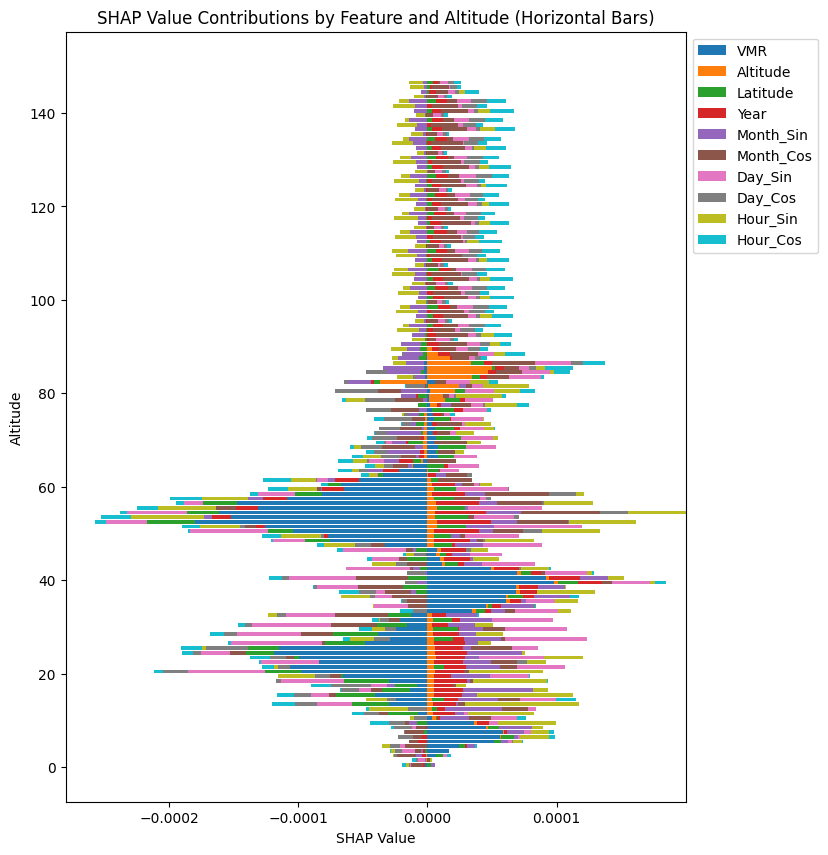

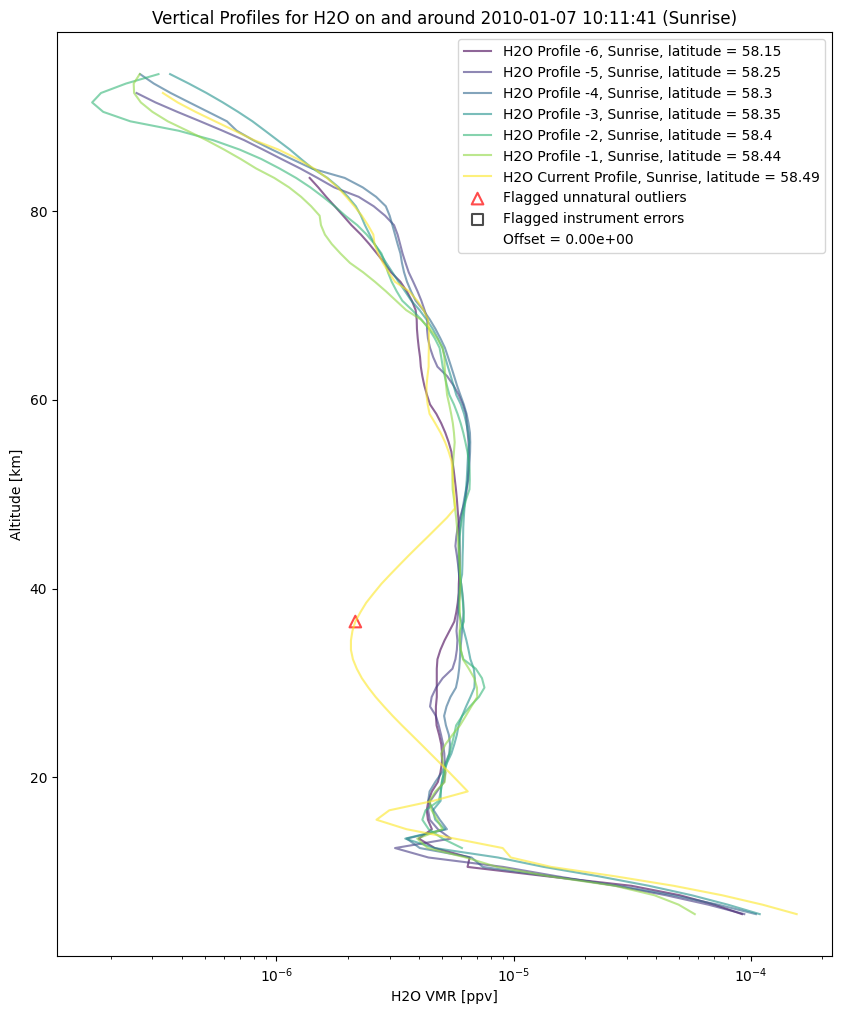

In [34]:
# Initialize cumulative sums for stacking
positive_cumulative = np.zeros_like(altitudes)
negative_cumulative = np.zeros_like(altitudes)

plt.figure(figsize=(8, 10))  # Adjust figure size for vertical altitude axis

for i, feature in enumerate(feature_names):
    # Extract SHAP values for the current feature
    feature_shap = current_profile_shap[0][:, i, 0]

    # Separate positive and negative contributions
    positive_contributions = np.maximum(0, feature_shap)
    negative_contributions = np.minimum(0, feature_shap)

    # Plot positive contributions
    plt.barh(
        altitudes,  # Altitudes on the vertical axis
        positive_contributions,
        left=positive_cumulative,  # Cumulative sum determines starting point
        label=feature,  # Label each feature only once
        color=f"C{i}"  # Unique color for each feature
    )
    positive_cumulative += positive_contributions  # Update positive stack

    # Plot negative contributions
    plt.barh(
        altitudes,  # Altitudes on the vertical axis
        negative_contributions,
        left=negative_cumulative,  # Cumulative sum determines starting point
        color=f"C{i}"  # Same color as the positive for this feature
    )
    negative_cumulative += negative_contributions  # Update negative stack

# Plot labels and legend
plt.ylabel("Altitude")  # Altitude along vertical axis
plt.xlabel("SHAP Value")  # SHAP value along horizontal axis
plt.title("SHAP Value Contributions by Feature and Altitude (Horizontal Bars)")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))  # Adjust legend position
plt.show()

vpp('H2O', h2o_data, h2o_flags, date_indices_example)


Overall SHAP Value for the Current Profile: 0.33288836511069064


<BarContainer object of 150 artists>

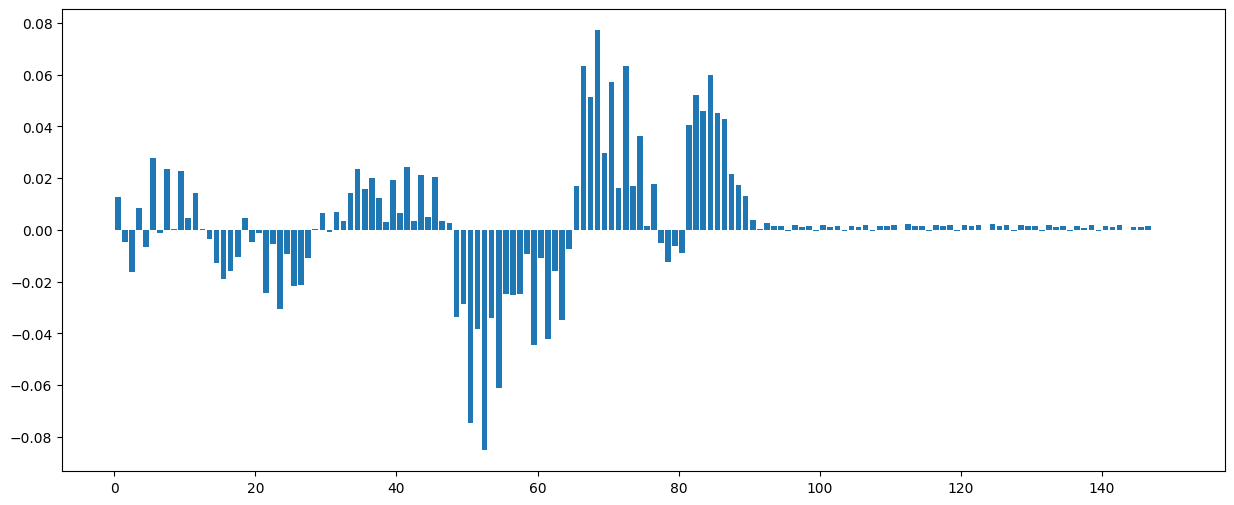

In [123]:
# Remove batch dimension and sum over altitude, feature, and SHAP dimensions
overall_shap_value = np.sum(current_profile_shap[0], axis=(0,1,2))

print(f"Overall SHAP Value for the Current Profile: {overall_shap_value}")

altitude_shap_value = np.sum(current_profile_shap[0], axis=(1,2))

plt.figure(figsize=(15, 6))
plt.bar(altitudes, altitude_shap_value.flatten())


(5, 150, 10, 1)
(5,)


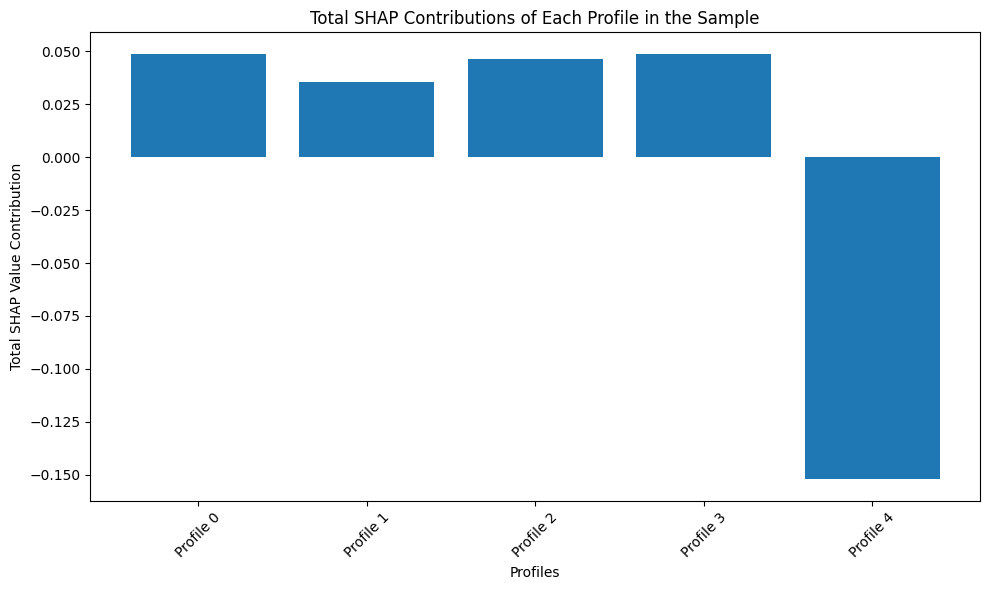

In [178]:
# Extract SHAP values for the entire sample
# Assuming `shap_values` is the SHAP output for the sample and has shape (1, 5, 150, 10, 1)
shap_values_sample = shap_values[0][0]  # Shape: (5, 150, 10, 1)
print(shap_values_sample.shape)

# Sum SHAP values across all features and profiles
profile_contributions = np.sum(shap_values_sample, axis=(1, 2, 3))  # Shape: (5,)
print(profile_contributions.shape)

# Create x-axis labels for profiles
profile_indices = [f"Profile {i}" for i in range(len(profile_contributions))]

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(profile_indices, profile_contributions)
plt.xlabel("Profiles")
plt.ylabel("Total SHAP Value Contribution")
plt.title("Total SHAP Contributions of Each Profile in the Sample")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [180]:
total_shap = np.sum(profile_contributions)
print(total_shap)

0.027026290729584623


In [184]:
# Access the expected value (baseline) from the SHAP explainer
baseline = explainer.expected_value
print("Baseline (Expected Value):", baseline)


Baseline (Expected Value): [0.07318301]


(1, 5, 150, 10)
(1, 5, 150, 10)


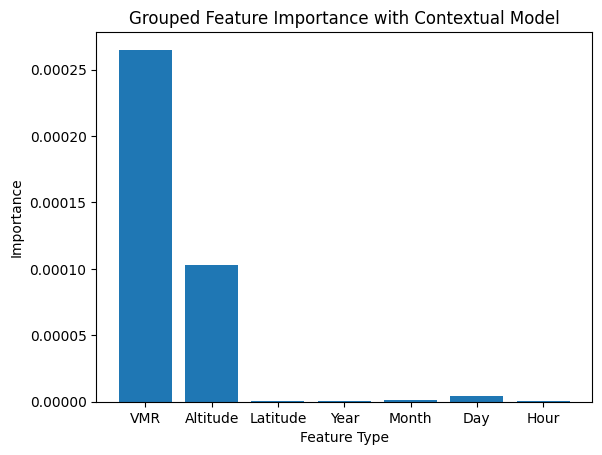

In [419]:
# Feature importance for contextual model in making predictions for specificly randomly sampled sample


X_test_sample = X_test[idx]
X_test_sample = X_test_sample[np.newaxis, ...]
print(X_test_sample.shape)
X_test_sample_indicators = X_test_indicators[idx]
X_test_sample_indicators = X_test_sample_indicators[np.newaxis, ...]
X_test_sample_indicators_perturbed = X_test_sample_indicators.copy()

# Compute saliency
saliency = compute_saliency_with_contextual_attention(model, X_test_sample, X_test_sample_indicators)
print(saliency.shape)

# Aggregate saliency over profiles and altitudes
feature_importance = np.mean(saliency, axis=(0, 1, 2))  # Aggregate across samples, profiles, and altitudes
n_altitudes = len(h2o_data['altitude'].values)
n_features = 10

# Define feature groups
feature_groups = {
    "VMR": feature_importance[0],
    "Altitude": feature_importance[1],
    "Latitude": feature_importance[2],
    "Year": feature_importance[3],
    "Month": np.sum(feature_importance[4:6]),
    "Day": np.sum(feature_importance[6:8]),
    "Hour": np.sum(feature_importance[8:10]),
}

# Visualize grouped feature importance
plt.bar(feature_groups.keys(), feature_groups.values())
plt.xlabel("Feature Type")
plt.ylabel("Importance")
plt.title("Grouped Feature Importance with Contextual Model")
plt.show()

In [420]:
reduced_saliency = saliency[0]
print(reduced_saliency.shape)

# Assuming saliency is an array with the following structure:
# saliency[:, :, month_sin, month_cos, day_sin, day_cos, hour_sin, hour_cos]
month_sin_index = 4
month_cos_index = 5
day_sin_index = 6
day_cos_index = 7
hour_sin_index = 8
hour_cos_index = 9

# Extract saliency values for sine and cosine components
month_sin_saliency = reduced_saliency[:, :, month_sin_index]
month_cos_saliency = reduced_saliency[:, :, month_cos_index]

day_sin_saliency = reduced_saliency[:, :, day_sin_index]
day_cos_saliency = reduced_saliency[:, :, day_cos_index]

hour_sin_saliency = reduced_saliency[:, :, hour_sin_index]
hour_cos_saliency = reduced_saliency[:, :, hour_cos_index]

# Combine sine and cosine saliencies using the Euclidean norm
month_saliency_combined = np.sqrt(month_sin_saliency**2 + month_cos_saliency**2)
day_saliency_combined = np.sqrt(day_sin_saliency**2 + day_cos_saliency**2)
hour_saliency_combined = np.sqrt(hour_sin_saliency**2 + hour_cos_saliency**2)

# Replace sine and cosine components in the saliency array with the combined values
# Assuming indices [month_sin_index, month_cos_index] are consecutive and similar for day/hour
combined_saliency = np.copy(reduced_saliency)
combined_saliency[:, :, month_sin_index] = month_saliency_combined
combined_saliency[:, :, day_sin_index] = day_saliency_combined
combined_saliency[:, :, hour_sin_index] = hour_saliency_combined

# Optionally, you can remove the cosine components if you no longer need them
combined_saliency = np.delete(combined_saliency, [month_cos_index, day_cos_index, hour_cos_index], axis=-1)

print("Combined saliency shape:", combined_saliency.shape)


(5, 150, 10)
Combined saliency shape: (5, 150, 7)


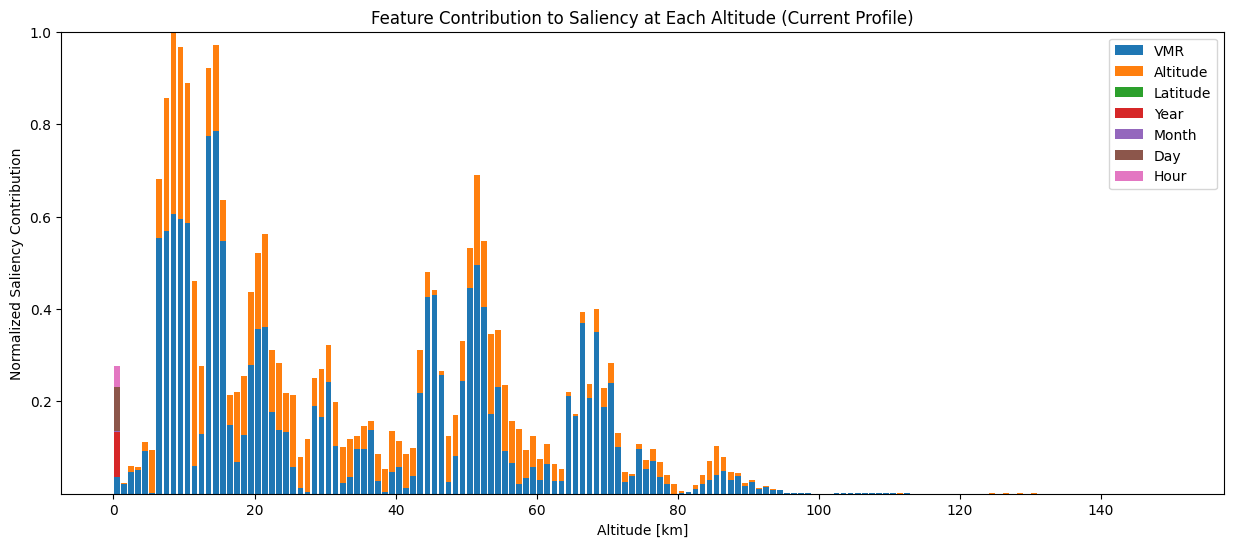

In [347]:
# Assuming saliency has shape (n_profiles, n_altitudes, n_features)
# For the current profile:
current_profile_saliency = combined_saliency[-1]  # Shape: (n_altitudes, n_features)

# Normalize across all altitude levels by dividing by the maximum saliency value in the entire array
max_saliency = np.max(np.sum(current_profile_saliency, axis=-1, keepdims=True))  # Find the global maximum saliency
normalized_saliency = current_profile_saliency / max_saliency  # Add epsilon to avoid division by zero

# Create a stacked bar plot
n_altitudes = normalized_saliency.shape[0]
n_features = normalized_saliency.shape[1]
feature_names = ["VMR", "Altitude", "Latitude", "Year", "Month", "Day", "Hour"]  # Update feature names

# Transpose for easier plotting
normalized_saliency_transposed = normalized_saliency.T  # Shape: (n_features, n_altitudes)

# Plot
altitudes = h2o_data['altitude'].values
# Assuming altitudes is a 1D array with the altitude values corresponding to each index
plt.figure(figsize=(15, 6))
plt.bar(
    altitudes,  # Use altitude values for x-axis
    normalized_saliency[:, 0],  # Plot the first feature's normalized contribution
    label='VMR'
)
bottom = normalized_saliency[:, 0]
for i in range(1, normalized_saliency.shape[1]):
    plt.bar(
        altitudes,  # Use altitude values for x-axis
        normalized_saliency[:, i],  # Plot other features' normalized contributions
        bottom=bottom,
        label=feature_names[i]
    )
    bottom += normalized_saliency[:, i]

plt.title("Feature Contribution to Saliency at Each Altitude (Current Profile)")
plt.xlabel("Altitude [km]")  # Update axis label
plt.ylabel("Normalized Saliency Contribution")
plt.legend(loc='upper right')
plt.show()


In [64]:
t = np.max(np.sum(current_profile_saliency, axis = -1, keepdims = True))
print(t)

0.1667869


In [57]:
print(combined_saliency)

[[[3.95536517e-05 4.63212236e-05 7.78325339e-05 ... 1.54705504e-05
   2.66791794e-05 8.26446649e-06]
  [2.41996255e-04 2.65699055e-05 5.44901486e-05 ... 6.49464346e-05
   6.98176373e-05 2.12049399e-05]
  [5.20851521e-04 1.48774547e-04 1.68711704e-05 ... 1.14448980e-04
   1.23520367e-04 3.93534392e-05]
  ...
  [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   0.00000000e+00 0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   0.00000000e+00 0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   0.00000000e+00 0.00000000e+00]]

 [[8.59840948e-05 1.16540701e-04 1.78001428e-04 ... 1.51696542e-04
   1.45991071e-04 1.15530049e-04]
  [6.31810399e-04 1.21624704e-04 7.06360515e-05 ... 1.56526075e-04
   1.75092791e-04 1.55478992e-04]
  [1.42539339e-03 2.88818643e-04 8.95755365e-05 ... 1.12248679e-04
   3.05657479e-04 8.15204112e-06]
  ...
  [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   0.00000

587/587 [==============================] - 2s 2ms/step
[[0.03087077 0.0499058  0.04539936 0.05339442 0.8204297 ]
 [0.01521776 0.05089145 0.04852334 0.07085613 0.8145113 ]
 [0.00570237 0.01998743 0.04349141 0.04950203 0.8813167 ]
 [0.00305624 0.01330055 0.02255844 0.05773037 0.90335435]
 [0.00109311 0.00355895 0.00934868 0.02102763 0.9649716 ]]
[0.01118805 0.02752883 0.03386424 0.05050212 0.87691677]


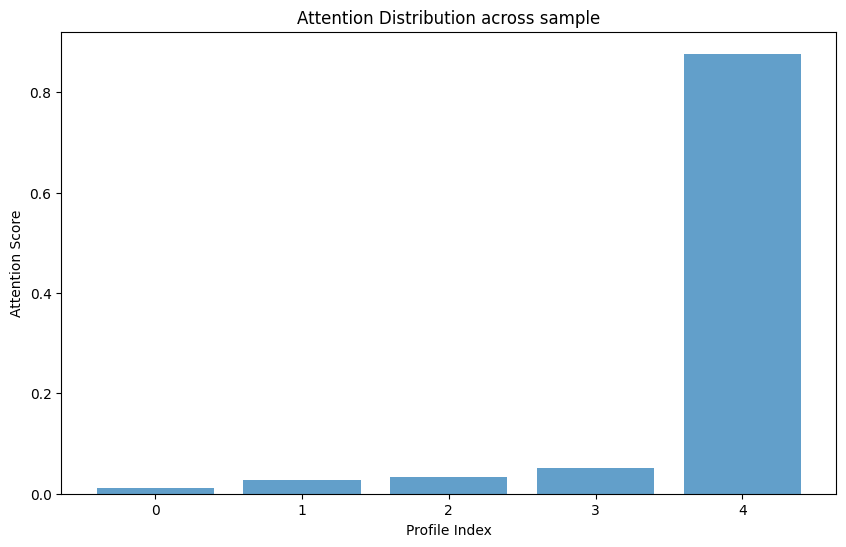

In [422]:
# Attention level for each profile (averaged) after introduction of custom attention mechanism

# Define a separate model to output attention scores
attention_extractor = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer('contextual_attention_44').output[1]  # Extract attention weights
)

# Predict attention scores for a subset of the test data
attention_scores = attention_extractor.predict([X_test, X_test_indicators])[idx]

print(attention_scores)

profile_contributions = np.sum(attention_scores, axis=0)  # Average over samples

profile_contributions = profile_contributions/np.sum(profile_contributions)
print(profile_contributions)


plt.figure(figsize=(10, 6))
plt.bar(range(n_profiles), profile_contributions, alpha=0.7)  # Attention for profile 4
plt.title(f"Attention Distribution across sample")
plt.xlabel("Profile Index")
plt.ylabel("Attention Score")
plt.show()

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 5, 150,    │          0 │ -                 │
│ (InputLayer)        │ 10)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 5, 4608)   │     26,688 │ input_layer[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 5, 128)    │  2,425,344 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ contextual_attenti… │ [(None, 5, 128),  │          0 │ lstm[0][0],       │
│ (ContextualAttenti… │ (None, 5, 5)]     │            │ lstm[0][0],       │
│                     │                   │            │ lstm[0][0],       │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ contextual_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,381,061 (28.16 MB)

 Trainable params: 2,460,353 (9.39 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,920,708 (18.77 MB)

In [61]:
# Define a separate model to output attention scores
attention_extractor = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer("attention").output  # Replace with the actual index or name
)

# Predict attention scores for a subset of the test data
attention_scores = attention_extractor.predict(X_test[:2000])

print("Attention Scores Shape:", attention_scores.shape)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Attention Scores Shape: (2000, 5, 128)


587/587 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step


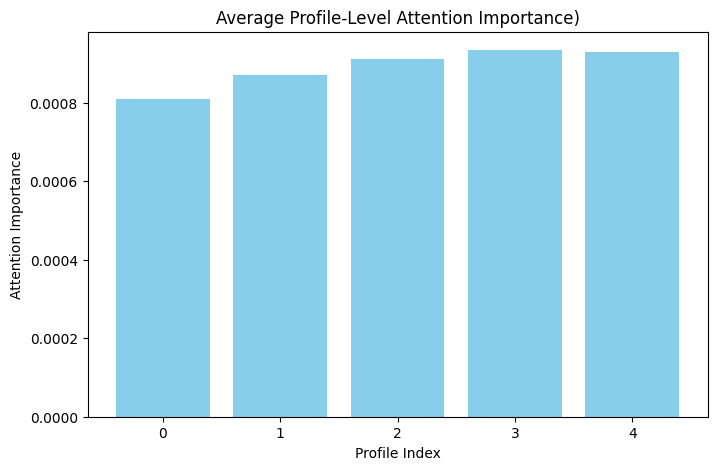

In [ ]:
# Attention level of each profile (averaged) prior to introduction of custom attention mechanism

random_indices = np.random.choice(X_test.shape[0], 2000, replace=False)
X_test_sample = X_test[random_indices]

attention_scores = attention_extractor.predict(X_test)

# Aggregate attention scores across the feature dimension (axis=-1)
profile_importance = np.mean(attention_scores, axis=-1)  # Shape: (n_samples, n_profiles)

average_profile_importance = np.mean(profile_importance, axis=0)
sample_idx = 7

# Visualize attention for the first sample
plt.figure(figsize=(8, 5))
plt.bar(range(profile_importance.shape[1]), average_profile_importance, color='skyblue')
plt.xlabel("Profile Index")
plt.ylabel("Attention Importance")
plt.title(f"Average Profile-Level Attention Importance)")
plt.show()

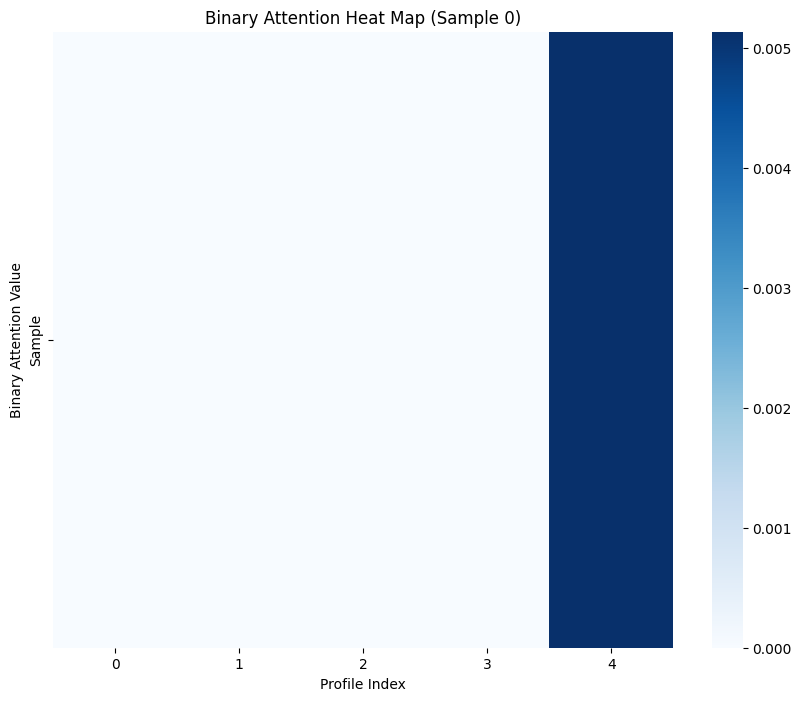

In [ ]:
# Attention heat map for the first sample prior to introduction of custom atttention mechanism

# Aggregate attention scores across the last axis (n_attention_scores)
attention_scores_aggregated = np.mean(attention_scores, axis=2)  # Shape: (n_samples, n_profiles)

# Extract binary indicators for all samples and profiles
binary_indicators = X_test[:, :, 0, -1]  # Shape: (n_samples, n_profiles), assuming indicator is at the last feature index

# Initialize binary attention maps
binary_attention_maps = np.zeros_like(attention_scores_aggregated)  # Shape matches aggregated scores

# Iterate over each sample
for sample_idx in range(binary_attention_maps.shape[0]):  # Loop over samples
    for profile_idx in range(binary_attention_maps.shape[1]):  # Loop over profiles
        if binary_indicators[sample_idx, profile_idx] == 1:  # Check if indicator is 1
            binary_attention_maps[sample_idx, profile_idx] = attention_scores_aggregated[sample_idx, profile_idx]

# Visualize binary attention heat map for the first sample
sample_index = 0  # Choose the sample to visualize
plt.figure(figsize=(10, 8))
sns.heatmap(binary_attention_maps[sample_index].reshape(1, -1),  # Use a single row for visualization
            annot=False, cmap="Blues", cbar=True, xticklabels=range(binary_attention_maps.shape[1]), yticklabels=["Sample"])
plt.title(f"Binary Attention Heat Map (Sample {sample_index})")
plt.xlabel("Profile Index")
plt.ylabel("Binary Attention Value")
plt.show()

587/587 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step
587/587 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step


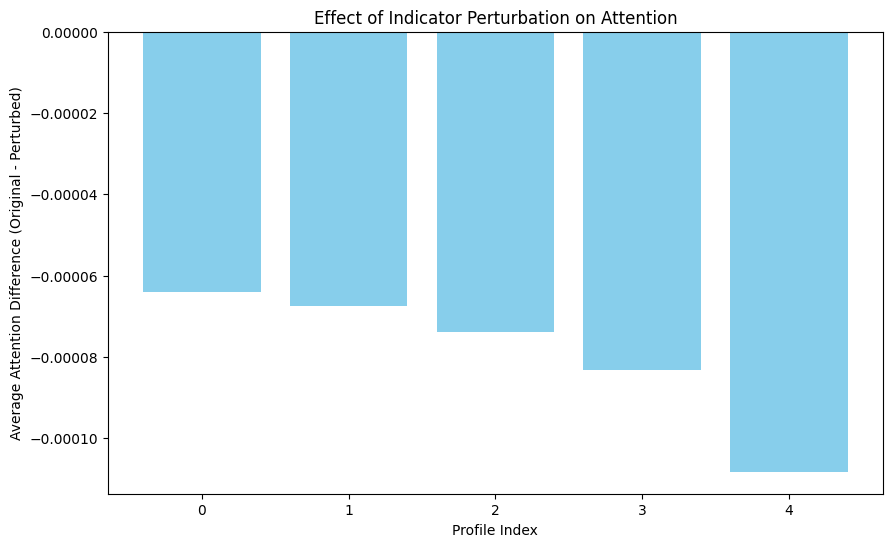

In [ ]:
# Change in attention per profile after perturbation of indicator feature prior to introduction of custom attention mechanism

X_test_perturbed = X_test.copy()
X_test_perturbed[:, :, :, -1] = 0  # Set all indicator values to 0

# Extract attention scores for original data
original_attention_scores = attention_extractor.predict(X_test)

# Extract attention scores for perturbed data
perturbed_attention_scores = attention_extractor.predict(X_test_perturbed)

original_attention_scores_aggregated = np.mean(original_attention_scores, axis=2)
perturbed_attention_scores_aggregated = np.mean(perturbed_attention_scores, axis=2)

# Compute the difference
attention_difference = original_attention_scores_aggregated - perturbed_attention_scores_aggregated

average_attention_difference = np.mean(attention_difference, axis=0)  # Shape: (n_profiles,)

# Visualize for a single sample (e.g., sample 0)
sample_index = 0
plt.figure(figsize=(10, 6))
plt.bar(range(attention_difference.shape[1]), average_attention_difference, color="skyblue")
plt.xlabel("Profile Index")
plt.ylabel("Average Attention Difference (Original - Perturbed)")
plt.title(f"Effect of Indicator Perturbation on Attention")
plt.show()



587/587 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step


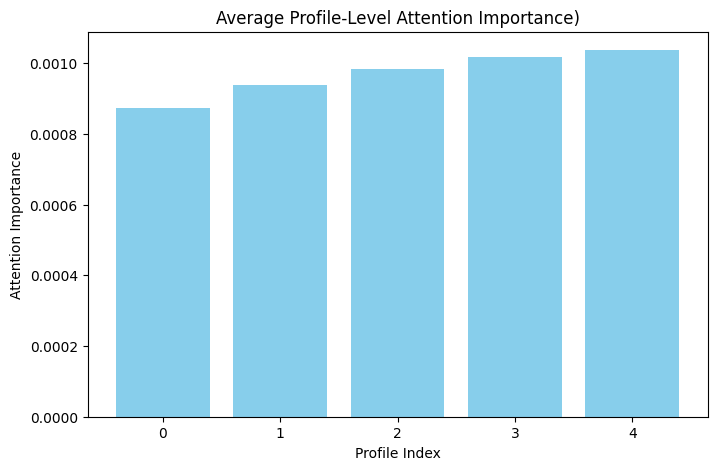

In [ ]:
# Attention level of each profile (averaged) after perturbation of indicator feature prior to introduction of custom attention mechanism

attention_scores = attention_extractor.predict(X_test_perturbed)

# Aggregate attention scores across the feature dimension (axis=-1)
profile_importance = np.mean(attention_scores, axis=-1)  # Shape: (n_samples, n_profiles)

average_profile_importance = np.mean(profile_importance, axis=0)
sample_idx = 7

# Visualize attention for the first sample
plt.figure(figsize=(8, 5))
plt.bar(range(profile_importance.shape[1]), average_profile_importance, color='skyblue')
plt.xlabel("Profile Index")
plt.ylabel("Attention Importance")
plt.title(f"Average Profile-Level Attention Importance)")
plt.show()

587/587 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step
[[0.14873669 0.14970048 0.14989056 0.14925617 0.402416  ]
 [0.14864242 0.15023915 0.15056248 0.14952618 0.4010298 ]
 [0.14855967 0.15028785 0.15066712 0.14959185 0.40089357]
 [0.14847465 0.14980203 0.15014167 0.14943841 0.4021433 ]
 [0.14843409 0.14897573 0.14919724 0.14911428 0.40427864]]
[0.14437325 0.14702067 0.14893392 0.15013275 0.40954468]


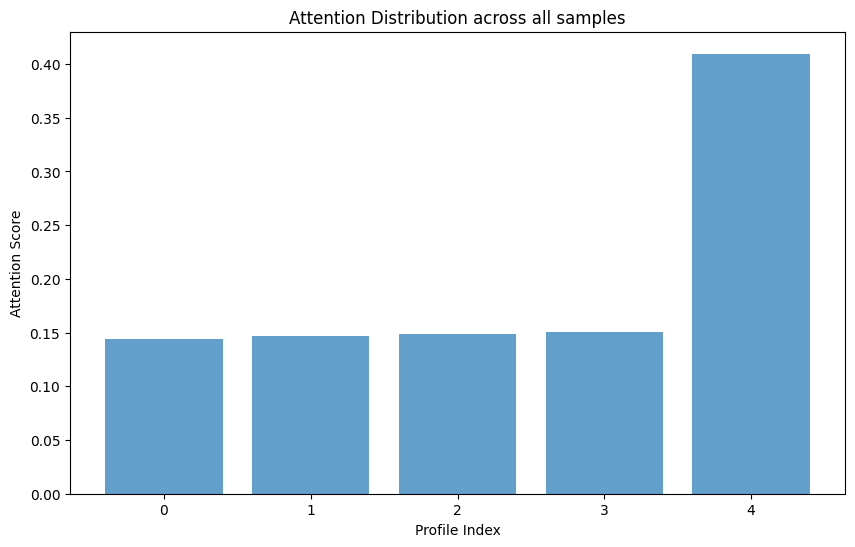

In [ ]:
# Attention level for each profile (averaged) after introduction of custom attention mechanism

# Define a separate model to output attention scores
attention_extractor = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer('contextual_attention').output[1]  # Extract attention weights
)

# Predict attention scores for a subset of the test data
attention_scores = attention_extractor.predict([X_test, X_test_indicators])

print(attention_scores[0])

average_attention_scores = np.mean(attention_scores, axis=(0,1))  # Average over samples

print(average_attention_scores)


plt.figure(figsize=(10, 6))
plt.bar(range(n_profiles), average_attention_scores, alpha=0.7)  # Attention for profile 4
plt.title(f"Attention Distribution across all samples")
plt.xlabel("Profile Index")
plt.ylabel("Attention Score")
plt.show()

  1/587 ━━━━━━━━━━━━━━━━━━━━ 1:42 175ms/step

/Users/jamesharvey/MPhys_Project/.venv/lib/python3.10/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor', 'keras_tensor_1']. Received: the structure of inputs=('*', '*')
  warnings.warn(


587/587 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step
[[0.19947937 0.20077197 0.20102689 0.20017609 0.19854574]
 [0.19911887 0.20125785 0.20169096 0.20030275 0.19762953]
 [0.19898508 0.20129983 0.20180786 0.20036758 0.19753958]
 [0.19908185 0.20086165 0.20131706 0.20037411 0.19836529]
 [0.19938834 0.20011593 0.20041348 0.20030205 0.19978021]]
[0.19476327 0.19835664 0.20097363 0.20258676 0.20331989]


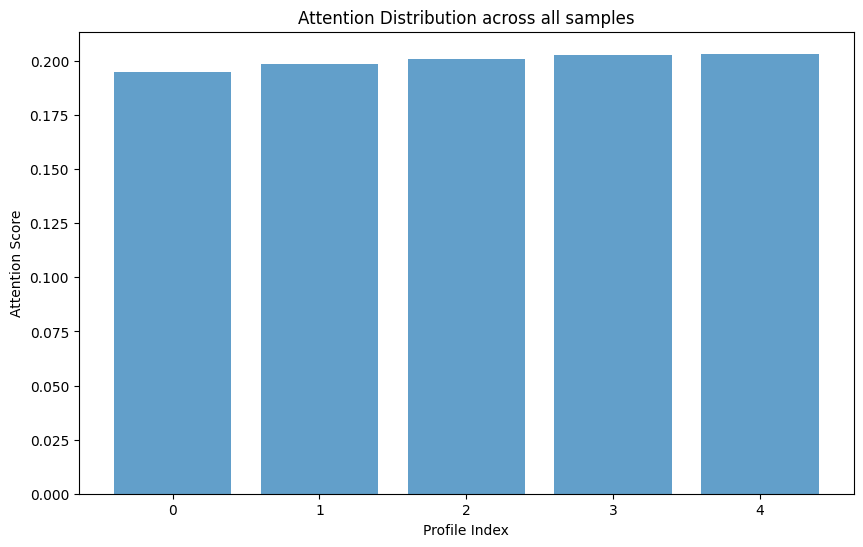

In [ ]:
# Attention level per profile after perturbation of indicator feature after introduction of custom attention mechanism

X_test_indicators_perturbed = X_test_indicators.copy()
X_test_indicators_perturbed[:,4] = 0

# Define a separate model to output attention scores
attention_extractor = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer('contextual_attention').output[1]  # Extract attention weights
)

# Predict attention scores for a subset of the test data
attention_scores = attention_extractor.predict([X_test, X_test_indicators_perturbed])

print(attention_scores[0])

average_attention_scores = np.mean(attention_scores, axis=(0,1))  # Average over samples

print(average_attention_scores)


plt.figure(figsize=(10, 6))
plt.bar(range(n_profiles), average_attention_scores, alpha=0.7)  # Attention for profile 4
plt.title(f"Perturbed Attention Distribution across all samples")
plt.xlabel("Profile Index")
plt.ylabel("Attention Score")
plt.show()

In [58]:
def compute_saliency_with_contextual_attention(model, X, indicators):
    """
    Compute saliency with the contextual attention model.
    """
    X_tensor = tf.convert_to_tensor(X)
    indicators_tensor = tf.convert_to_tensor(indicators)

    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        predictions = model([X_tensor, indicators_tensor])
    gradients = tape.gradient(predictions, X_tensor)
    return np.abs(gradients.numpy())

# Sample

(2000, 5, 150, 10)


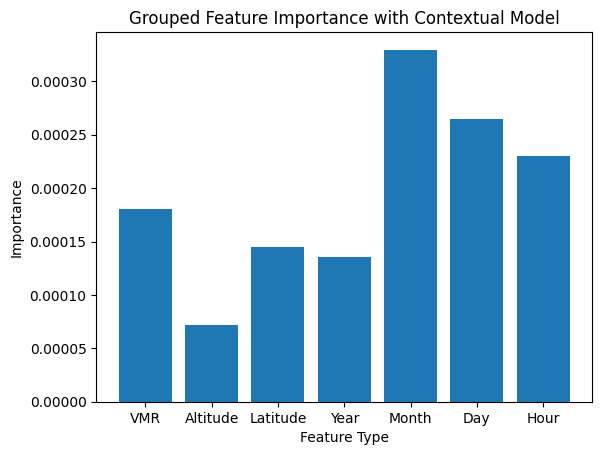

In [32]:
# Sample random indices for evaluation
random_indices = np.random.choice(X_test.shape[0], 2000, replace=False)
X_test_sample = X_test[random_indices]
X_test_sample_indicators = X_test_indicators[random_indices]
X_test_sample_indicators_perturbed = X_test_sample_indicators.copy()

# Compute saliency
saliency = compute_saliency_with_contextual_attention(model, X_test_sample, X_test_sample_indicators)
print(saliency.shape)

# Aggregate saliency over profiles and altitudes
feature_importance = np.mean(saliency, axis=(0, 1, 2))  # Aggregate across samples, profiles, and altitudes
n_altitudes = len(h2o_data['altitude'].values)
n_features = 10

# Define feature groups
feature_groups = {
    "VMR": feature_importance[0],
    "Altitude": feature_importance[1],
    "Latitude": feature_importance[2],
    "Year": feature_importance[3],
    "Month": np.sum(feature_importance[4:6]),
    "Day": np.sum(feature_importance[6:8]),
    "Hour": np.sum(feature_importance[8:10]),
}

# Visualize grouped feature importance
plt.bar(feature_groups.keys(), feature_groups.values())
plt.xlabel("Feature Type")
plt.ylabel("Importance")
plt.title("Grouped Feature Importance with Contextual Model")
plt.show()